In [1]:
import numpy as np
import os 
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from PIL import Image
from skimage.metrics import structural_similarity as ssim

In [2]:
sigma: [15,80,250]
weights: [1,1,1]
alpha: 125
beta: 46
high_clip: 0.001
low_clip: 0.001
gamma: 0.6

In [3]:
def single_scale_Retinex(raw_img, sigma):
    log_img = np.log10(raw_img) - np.log10(cv2.GaussianBlur(raw_img, (0, 0), sigma)) # sigma = 15
    return log_img


In [4]:
def multi_scale_Retinex(raw_img, sigma_arr, weight_arr):
    while len(weight_arr) < len(sigma_arr):
        weight_arr.append(0)
    weight_sum = sum(weight_arr)

    img = np.zeros(raw_img.shape)
    for i in range(len(sigma_arr)):
        w = weight_arr[i] / weight_sum
        img += single_scale_Retinex(raw_img, sigma_arr[i]) * w
    
    return img

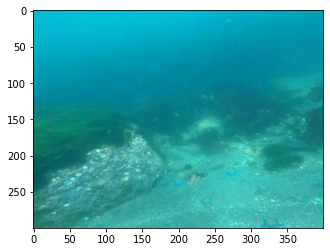

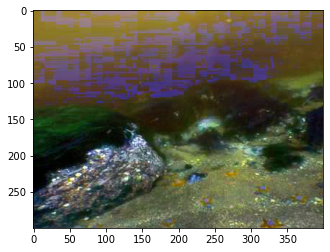

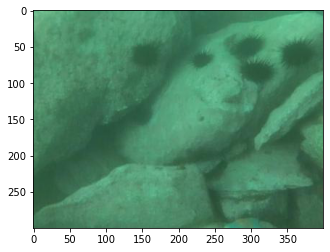

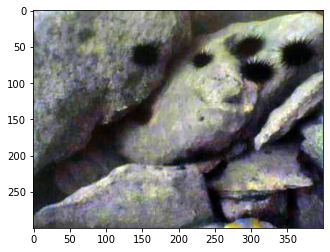

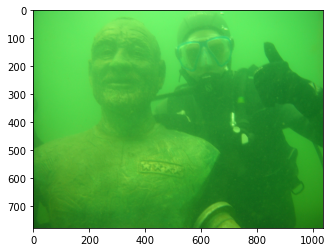

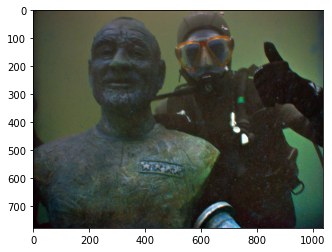

In [5]:
def create_gamma_lookup_table(gamma):
    lut = list(range(0, 256))
    if gamma != 0:
        for i in range(0,256):
            lut[i] = int((i / 255) ** (1 / gamma) * 255)
    return lut



def quantify_log_image(img, high_clip=0.005, low_clip=0.005, gamma=0.45):
    lut = create_gamma_lookup_table(gamma)

    for c in range(img.shape[-1]):
        flatten = sorted(img[:,:,c].ravel())
        low = flatten[int(len(flatten) * low_clip)]
        high = flatten[int(len(flatten) * (1 - high_clip))]
        # plt.hist(flatten, 200, [min(flatten), max(flatten)])
        # plt.show()
        temp = np.minimum(np.maximum(img[:,:,c], low), high)
        temp = np.uint8((temp - low) / (high - low) * 255.0)

        # Gamma correction.
        if gamma != 0:
            for i in range(temp.shape[0]):
                for j in range(temp.shape[1]):
                    temp[i][j] = lut[temp[i][j]]
                
        img[:,:,c] = temp

    return np.uint8(img)

def MSR_color_restoration(original_img, sigma_arr, weight_arr, alpha=125, beta=46, high_clip=0.005, low_clip=0.005,gamma=0.45):
    original_img = np.float64(original_img) + 1.0 # Avoiding numerical unstability cause by log(0) in SSR

    # Basic Multiscale Retinex
    R = multi_scale_Retinex(original_img, sigma_arr, weight_arr)

    # Calculate color restoration function(CRF)
    sigmaI = original_img.sum(axis=2)
    # Expand dims to 3 channels, copy data at (1080,1920,0) along 2nd axis. Expanditure is required for the 2nd axis does not exist.
    sigmaI = np.expand_dims(sigmaI, axis=2).repeat(3, axis=2)
    CRF = beta * (np.log10(alpha * original_img) - np.log10(sigmaI))

    # Quantify
    img = quantify_log_image(CRF * R, high_clip, low_clip, gamma)

    # # Grayscale histogram for testing
    # plt.hist(img[:,:,0].ravel(), 200, [img[:,:,0].min(), img[:,:,0].max()])
    # plt.show()
    
    return img

inpath = r'C:\Users\user-name\folder-name\images_dataset'
outpath = r'C:\Users\user-name\folder-name\MSRCR_OUTPUT'
filenames = glob.glob(inpath+"\*.*")
for f in filenames:
    file,ext = os.path.splitext(f)
#    img = cv2.imread((file+ext))
    img = Image.open(file+ext)
    opencvImage = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    plt.imshow(mpimg.imread(file+ext))
    plt.show()
    processed_img = MSR_color_restoration(img,[15,80,250], [1,1,1],125,46,0.001,0.001,0.6)
#     cv2.imshow("Original Image",im)
#     cv2.imshow("Processed Image",processed_img)
#     cv2.waitKey()
    processed_img = cv2.cvtColor(np.array(processed_img), cv2.COLOR_BGR2RGB)
    img=Image.fromarray(processed_img)
    save_file_name = os.path.join(outpath,os.path.basename(file)+ext)
    img.save(save_file_name)
    plt.imshow(mpimg.imread(save_file_name))
    plt.show()

In [6]:
inpath = r'C:\Users\user-name\folder-name\images_dataset'
outpath = r'C:\Users\user-name\folder-name\MSRCR_OUTPUT'
in_file = glob.glob(inpath+"\*.*")
out_file = glob.glob(outpath+"\*.*")
PSNR = []
SSIM = []
for i in range(len(in_file)):
    o_file,o_ext=os.path.splitext(in_file[i])
    p_file,p_ext=os.path.splitext(out_file[i])
    in_img = Image.open(o_file+o_ext)
    out_img = Image.open(p_file+p_ext)
    #print(np.sqrt(np.mean(np.array(out_img)-np.mean(np.array(out_img),axis=(0,1)))))
    in_img_arr = cv2.cvtColor(np.array(in_img),cv2.COLOR_RGB2BGR)
    out_img_arr=cv2.cvtColor(np.array(out_img),cv2.COLOR_RGB2BGR)
#     print("Input Image")
#     plt.imshow(mpimg.imread(o_file+o_ext))
#     plt.show()
#     print("Processed Image")
#     plt.imshow(mpimg.imread(p_file+p_ext))
#     plt.show()
    PSNR.append(cv2.PSNR(out_img_arr,in_img_arr))
    SSIM.append(ssim(cv2.cvtColor(out_img_arr,cv2.COLOR_BGR2GRAY),cv2.cvtColor(in_img_arr,cv2.COLOR_BGR2GRAY)))
    #print("Peak Signal to Noise Ratio =",cv2.PSNR(out_img_arr,in_img_arr))
    #print("Structure Similarity Index = ",ssim(cv2.cvtColor(out_img_arr,cv2.COLOR_BGR2GRAY),cv2.cvtColor(in_img_arr,cv2.COLOR_BGR2GRAY)))
#     print(cv2.PSNR(out_img_arr,in_img_arr))

# MSRCR Model

In [7]:
PSNR

[9.656832638738969, 14.69472923445303, 11.816366064861546]

In [8]:
SSIM

[0.7197335289586827, 0.6017624671337365, 0.6302919425058007]